# 1. Importar Librerías Necesarias
Cargamos las librerías principales para procesamiento de imágenes, TensorFlow y manipulación de datos.

In [ ]:

import os
import cv2
import numpy as np
import tensorflow as tf
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# 2. Verificar GPU
Verificamos si TensorFlow puede acceder a la GPU disponible.

In [ ]:
import cv2
import numpy as np

IMG_SIZE = 224
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def procesar_imagen(ruta):
    # 1. Leer en escala de grises
    img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)

    if img is None:
        return None

    # 2. Resize
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # 3. Reducir ruido
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # 4. Mejorar contraste
    img = clahe.apply(img)

    # 5. Convertir a RGB 
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    return img

# 3. Función de Procesamiento de Imágenes
Define la función para procesar cada imagen: redimensionar, reducir ruido, mejorar contraste y normalizar.

In [3]:
def cargar_dataset(ruta_dataset):
    X = []
    y = []

    clases = ["cancer", "no_cancer"]

    for idx, clase in enumerate(clases):
        ruta_clase = os.path.join(ruta_dataset, clase)

        print(f"Cargando {clase}...")

        for img_nombre in tqdm(os.listdir(ruta_clase)):
            ruta_img = os.path.join(ruta_clase, img_nombre)

            img = procesar_imagen(ruta_img)

            if img is not None:
                X.append(img)
                y.append(idx)

    return np.array(X), np.array(y)

# 4. Función para Cargar Dataset
Define la función que carga todas las imágenes del dataset y aplica el procesamiento a cada una.

In [4]:
ruta_dataset = "dataset_expandido"

X, y = cargar_dataset(ruta_dataset)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Cargando cancer...


100%|██████████| 5688/5688 [00:20<00:00, 279.13it/s]


Cargando no_cancer...


100%|██████████| 5256/5256 [00:26<00:00, 200.50it/s]


Shape X: (10944, 224, 224, 3)
Shape y: (10944,)


# 5. Cargar Dataset Original
Cargar todas las imágenes del dataset original y mostrar sus dimensiones.

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (7660, 224, 224, 3)
Val: (1642, 224, 224, 3)
Test: (1642, 224, 224, 3)


# 6. Dividir Dataset en Train, Validación y Test
Dividir los datos: 70% entrenamiento, 15% validación, 15% test.

In [6]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# 7. Configurar Data Augmentation
Define técnicas de aumentación de datos: rotaciones, zoom y flips para mejorar generalización.

In [7]:
import tensorflow as tf
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 8. Importar Librerías Adicionales para Métricas
Importar librerías para visualización, métricas de evaluación y análisis de resultados.

In [8]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: 0.9620698317005777, 1: 1.0410437618918185}


# 9. Calcular Pesos de Clases
Calcular pesos automáticos para balancear clases desbalanceadas en el dataset.

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# 10. Crear Datasets de TensorFlow
Crear datasets optimizados para TensorFlow con batches y aplicar data augmentation al conjunto de entrenamiento.

In [10]:
BATCH_SIZE = 32

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(1000).batch(BATCH_SIZE)

train_dataset = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y)
)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

# 11. Construir Modelo ResNet50 con Capas Personalizadas
Cargar ResNet50 preentrenado, congelar capas base y agregar capas personalizadas para clasificación binaria.

In [11]:
base_model = tf.keras.applications.ResNet101(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Congelar capas
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)

output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=output)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 42,928,769 (163.76 MB)

 Trainable params: 266,497 (1.02 MB)

 Non-trainable params: 42,662,272 (162.74 MB)

# 12. Compilar Modelo
Compilar el modelo con optimizador Adam, pérdida binary crossentropy y métricas de evaluación.

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

# 13. Configurar Callbacks
Configurar Early Stopping y ReduceLROnPlateau para detener cuando no hay mejora y reducir learning rate.

In [13]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

# 14. Entrenar Modelo (Transfer Learning)
Entrenar el modelo con capas base congeladas usando transfer learning (30 épocas máximo).

In [14]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50


240/240 ━━━━━━━━━━━━━━━━━━━━ 436s 2s/step - accuracy: 0.7430 - loss: 0.5923 - precision: 0.7013 - recall: 0.8097 - val_accuracy: 0.8143 - val_loss: 0.4042 - val_precision: 0.7472 - val_recall: 0.9264 - learning_rate: 1.0000e-04
Epoch 2/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 427s 2s/step - accuracy: 0.7698 - loss: 0.4981 - precision: 0.7284 - recall: 0.8304 - val_accuracy: 0.8216 - val_loss: 0.3917 - val_precision: 0.7487 - val_recall: 0.9454 - learning_rate: 1.0000e-04
Epoch 3/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 429s 2s/step - accuracy: 0.7809 - loss: 0.4609 - precision: 0.7378 - recall: 0.8437 - val_accuracy: 0.8295 - val_loss: 0.3880 - val_precision: 0.7452 - val_recall: 0.9797 - learning_rate: 1.0000e-04
Epoch 4/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 451s 2s/step - accuracy: 0.7915 - loss: 0.4380 - precision: 0.7415 - recall: 0.8687 - val_accuracy: 0.8301 - val_loss: 0.3774 - val_precision: 0.7464 - val_recall: 0.9784 - learning_rate: 1.0000e-04
Epoch 5/50
240/240 ━━━━━━━━━━━━━━━━━━━━ 449s 2s/step - 

# 15. Fine-tuning: Entrenar Últimas Capas
Descongelar últimas 50 capas de ResNet50 y entrenar con learning rate bajo para ajustar el modelo (10 épocas máximo).

In [ ]:

for layer in base_model.layers[-100:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(train_dataset, validation_data=val_dataset, epochs=15)

Epoch 1/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 746s 3s/step - accuracy: 0.8367 - loss: 0.3539 - val_accuracy: 0.8575 - val_loss: 0.3050
Epoch 2/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 723s 3s/step - accuracy: 0.8582 - loss: 0.3065 - val_accuracy: 0.8666 - val_loss: 0.2907
Epoch 3/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 723s 3s/step - accuracy: 0.8695 - loss: 0.2855 - val_accuracy: 0.8624 - val_loss: 0.2887
Epoch 4/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 723s 3s/step - accuracy: 0.8785 - loss: 0.2624 - val_accuracy: 0.8745 - val_loss: 0.2654
Epoch 5/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 724s 3s/step - accuracy: 0.8886 - loss: 0.2543 - val_accuracy: 0.8843 - val_loss: 0.2562
Epoch 6/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 722s 3s/step - accuracy: 0.8990 - loss: 0.2313 - val_accuracy: 0.8959 - val_loss: 0.2266
Epoch 7/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 723s 3s/step - accuracy: 0.9059 - loss: 0.2191 - val_accuracy: 0.9032 - val_loss: 0.2228
Epoch 8/15
240/240 ━━━━━━━━━━━━━━━━━━━━ 722s 3s/step - accuracy: 0.9110 - loss: 0.2061 - val_accu

# 16. Evaluar Modelo en Conjunto de Test
Evaluar el modelo final en el conjunto de test y mostrar pérdida y métricas.

In [16]:
model.evaluate(test_dataset)

52/52 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.9227 - loss: 0.1924


[0.19240346550941467, 0.9226552844047546]

# 17. Generar Predicciones en Test
Generar predicciones probabilísticas y convertir a etiquetas binarias (umbral 0.5).

In [17]:
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.4).astype("int32")

52/52 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step


# 18. Reporte de Clasificación Detallado
Mostrar reporte detallado con precisión, recall, F1-score para cada clase.

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.86      0.92       853
           1       0.87      0.98      0.92       789

    accuracy                           0.92      1642
   macro avg       0.92      0.92      0.92      1642
weighted avg       0.93      0.92      0.92      1642



# 19. Matriz de Confusión
Visualizar la matriz de confusión para ver verdaderos positivos, falsos positivos, etc.

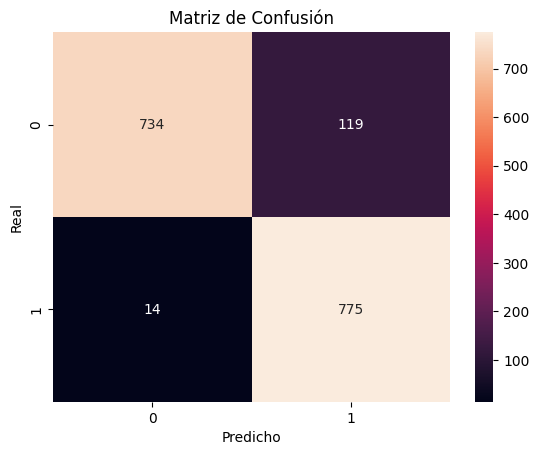

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

# 20. Gráficos de Accuracy y Loss
Visualizar el progreso del entrenamiento: accuracy y loss en train vs validación.

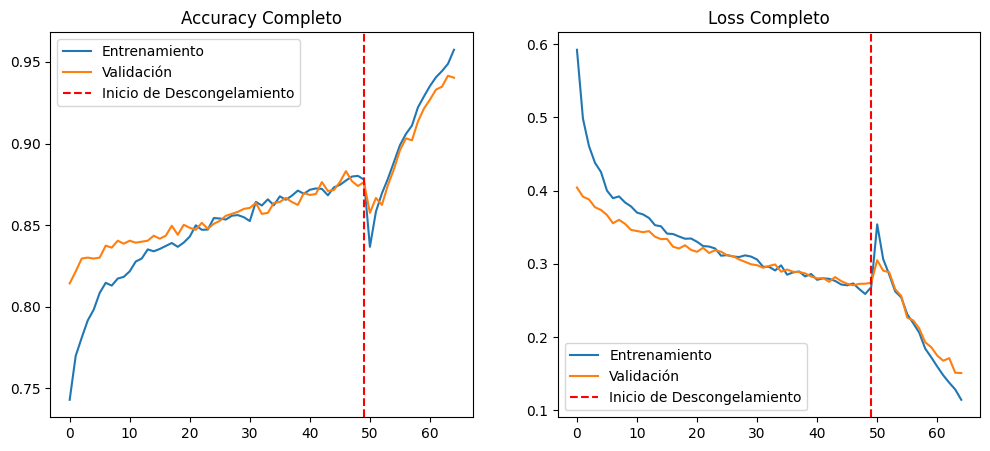

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

epochs_totales = range(len(acc))

plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(epochs_totales, acc, label='Entrenamiento')
plt.plot(epochs_totales, val_acc, label='Validación')
plt.axvline(x=len(history.history['accuracy'])-1, color='r', linestyle='--', label='Inicio de Descongelamiento')
plt.title('Accuracy Completo')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(epochs_totales, loss, label='Entrenamiento')
plt.plot(epochs_totales, val_loss, label='Validación')
plt.axvline(x=len(history.history['loss'])-1, color='r', linestyle='--', label='Inicio de Descongelamiento')
plt.title('Loss Completo')
plt.legend()

plt.show()

In [ ]:

model.save("ResNet101_binario.keras")